# Динамическая типизация

Типы в Python автоматически определяются во время выполнения, а не в ответ на объявление в коде. 

In [ ]:
a=3 # Мы не определили заранее, что это int

Переменная создается при первом присваивании ей значения. Переменная не располагает информацией о типе, т.к. тип обитает в объекте, а не в имени. 

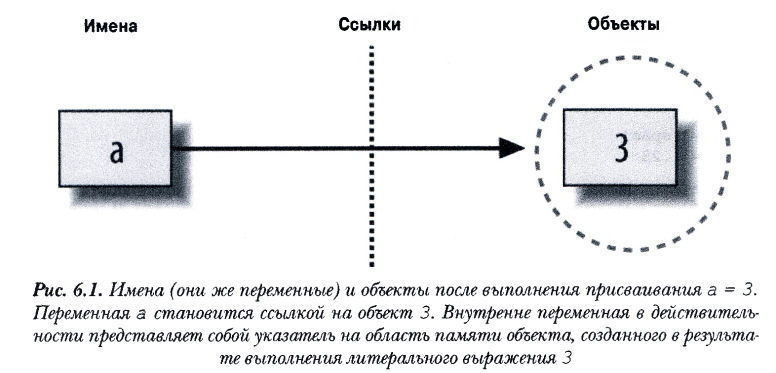

* Переменные — это записи в системной таблице, в которых предусмотрены места для связей с объектами
* Объекты — это области выделенной памяти с достаточным пространством для представления значений, для которых они предназначены.
* Ссылки — это следуемые указатели от переменных к объектам.

Каждый объект содержит 2 заголовочныъ поля:
* Обозначение типа - пометка типа объекта
* Счетчик ссылок, который используется для того, чтобы определить, когда можно освободить память, которую занимает объект

In [1]:
a=3
print(type(a))
a='SPAM'
print(type(a))
a=1.23
print(type(a))

<class 'int'>
<class 'str'>
<class 'float'>


!!! Типы обитают в объектах, а не в переменных. Имена не имеют типов, мы не изменяем тип переменной ``а``, мы просто делаем переменную ссылкой на объект другого типа.

Объектам известно какого они типа

In [2]:
a=3
print(type(a))
a='SPAM'
print(type(a))

<class 'int'>
<class 'str'>


В Python при присваивании нового объекта области памяти, занимаемая предыдущим объектом, освобождается в случае, если на него не ссылается любое другое имя. Это автоматическое совобождение памяти известно как **сборка мусора**

In [3]:
х = 42
х = "shrubbery"# Освободить память занимаемую 42
# (если нет ссылок где-то еще)
х = 3.1415# Освободить память, занимаемую 'shrubbery'
х = [1, 2, 3]# Освободить память, занимаемую 3.1415

Каждый раз, когда переменной присваивается  новый объект, Python освобождает память, занятую предыдущим объектом (если на него нет ссылок) -  т.е. область памяти объекта автоматически попадает в пул
свободного пространства, чтобы быть задействованной каким-то будущим объектом.


В каждом объекте за это свойство отвечает счетчик ссылок, который отслеживает число ссылок, указывающих на объект. 

Когда счетчик ссылок = 0, то область памяти автоматически освобождается. 

In [13]:
x = 42 # счетчик = 1
x = "shrubbery"# счетчик старого объекта = 0, нового=1
x = 3.1415
x = [1, 2, 3]

Автоматическая сборка мусора позволяет сократить длину кода (относительно ЯП, в которых надо управлять памятью, вроде C++). 

! Но у счетчика ссылок есть классическая проблема циклических ссылок. 

In [5]:
L=[1,2,3]
L.append(L)
L

[1, 2, 3, [...]]

## Вызов счетчика ссылок

In [14]:
import sys
sys.getrefcount(x)

2

Т.к. 1 используется в IDLE, то у него будет большой счетчик ссылок

In [30]:
import sys
sys.getrefcount(1) 

1000011446

## Разделяемые ссылки

In [ ]:
a=3
b=a

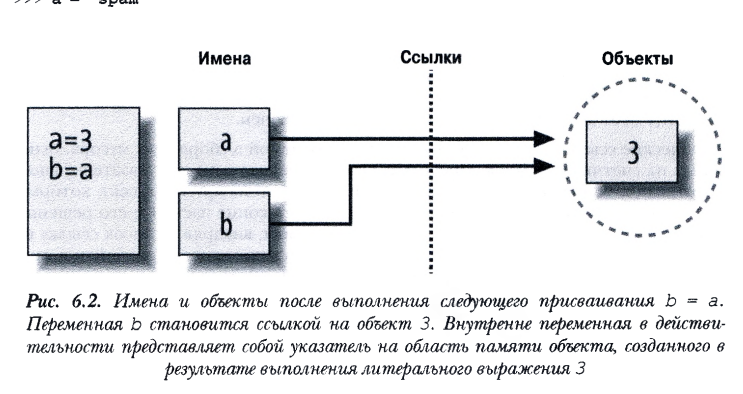

Обе переменные ссылаются на один и тот же объект. 

In [16]:
a=3
b=a
a='spam'
print(b)

3


Для неизменяемых объектов само присваивание переменной влияет только на одну
переменную, которой производится присваивание. 

Однако когда задействованы изменяемые объекты и изменения на месте, картина становится несколько иной.

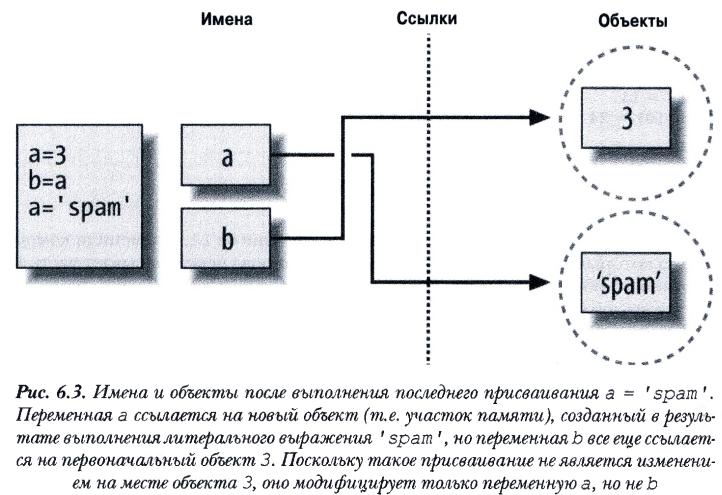

## Изменяемые объекты

In [18]:
L1=[2,3,4]
L2=L1
L1=24
print(L2)

[2, 3, 4]


In [20]:
L1=[2,3,4] # Изменяемый объект
L2=L1 # Создаем ссылку на тот же объект
L1[0]=24 # Изменение на месте 
print(L2) #

[24, 3, 4]


Мы не модифицировали сам список L1, а изменили компонент объекта, на который L1 ссылается. 

## Копирование объектов

In [21]:
L1=[2,3,4] # Изменяемый объект
L2=L1[:] # Создаем ссылку на тот же объект
L1[0]=24 # Изменение на месте 
print(L2) #

[2, 3, 4]


Для словарей и множеств для копирования нужно поступать следующим образом. 

In [24]:
import copy
X=copy.copy(Y) # Поверхностная копия
X=copy.deepcopy(Y) # Глубокая копия

## Одинаковые ли объекты

In [25]:
L= [1, 2, 3]
М = L # М и L ссылаются на один и тот же объект
print(L == М) # Одинаковые значения
print(L is М) # Одинаковые объекты

True
True


* Операция ``is`` проверяет на идентичность (совпадение) объектов в памяти.  Сравнивает указатели, которые реализуют ссылки. 

In [27]:
L = [1, 2, 3]
М = [1, 2, 3]
print(L == М)
print(L is М)

True
False


**НО:** для небольших целых чисел используются одни и те же объекты. 

In [28]:
x = 42
y = 42
print(x == y)
print(x is y)

True
True
